# Genetic toggle switch: bistability, switching, and memory

A synthetic genetic toggle switch (Gardner, Cantor & Collins, *Nature* 2000)
is built from two genes whose products mutually repress each other's
promoter: `U` represses the promoter driving `V`, and `V` represses the
promoter driving `U`. With sufficiently cooperative repression (a high Hill
coefficient), the circuit is bistable — it settles into one of two stable
states (`U` high / `V` low, or vice versa) and stays there even after any
transient perturbation is removed.

Each promoter's repression can be chemically relieved by an inducer that
inactivates the repressor — `IPTG` relieves `U`'s repression of `V`'s
promoter, `aTc` relieves `V`'s repression of `U`'s promoter (mirroring the
original IPTG/lacI and aTc/tetR implementation). Inducers are delivered as
`Field`s on the `Environment` and swapped in/out with
`colony.switch_environment()`, the same pattern `feature_tour.ipynb` uses
for a Plac-driven reporter.

This notebook drives the switch through a full induction cycle —
**equilibrate → induce to the opposite state → remove induction (memory)
→ induce back to the original state → remove induction again (memory)**
— in both a deterministic (ODE) and a stochastic (Gillespie SSA) single
cell, then animates a small growing colony through the same cycle.


In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from multicellular import Cell, Colony, Environment, Field, ReactionNetwork, Simulation
from multicellular.core.reactions import Reaction

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.dpi"] = 100


## 1. The toggle switch reaction network

Each gene's promoter activity follows a custom Hill-repression rate law:

```
synthesis rate = beta / (1 + (repressor_eff / K) ** n)
repressor_eff  = repressor / (1 + (inducer / K_ind) ** n_ind)
```

`repressor_eff` is the repressor's concentration discounted by how much
inducer has inactivated it — no inducer leaves it unchanged; a saturating
dose drives it toward zero, fully relieving repression. Both gene products
are degraded by simple first-order decay (and, in the growing colony below,
diluted by growth on top of that).


In [2]:
def repression_rate(reactant_conc, product_conc, catalyst_conc, params):
    repressor = catalyst_conc.get(params["repressor"], 0.0)
    inducer   = catalyst_conc.get(params["inducer"], 0.0)
    repressor_eff = repressor / (1.0 + (inducer / params["K_ind"]) ** params["n_ind"])
    return params["beta"] / (1.0 + (repressor_eff / params["K"]) ** params["n"])

# Kinetic parameters
beta, K, n, K_ind, n_ind, k_deg = 4.0, 1.0, 4.0, 1.0, 2.0, 1.0
rp = {"K": K, "n": n, "K_ind": K_ind, "n_ind": n_ind, "beta": beta}

# V-synthesis: repressed by U, de-repressed by IPTG
gene_v = Reaction({}, {"V": 1}, catalysts=["U", "IPTG"], rate_law_type="custom",
                  custom_rate_law=repression_rate,
                  rate_params={**rp, "repressor": "U", "inducer": "IPTG"})
# U-synthesis: repressed by V, de-repressed by aTc
gene_u = Reaction({}, {"U": 1}, catalysts=["V", "aTc"], rate_law_type="custom",
                  custom_rate_law=repression_rate,
                  rate_params={**rp, "repressor": "V", "inducer": "aTc"})
deg_u = Reaction({"U": 1}, {}, rate_law_type="mass_action", rate_params={"k": k_deg})
deg_v = Reaction({"V": 1}, {}, rate_law_type="mass_action", rate_params={"k": k_deg})


## 2. Deterministic switching and memory (single cell, time series)

A single non-growing cell (`growth_rate=0.0`, isolating the switch dynamics
from growth dilution) is started biased toward the `U`-high state and run
through the induction protocol with `ReactionNetwork`'s default `"ODE"`
(forward-Euler) integration.


In [3]:
shape, bounds = (5, 5), (50.0, 50.0)
phase_duration = 30.0

# Named environments for each induction condition
no_inducer = Environment("No Inducer", wall_map=np.zeros(shape), size=bounds, fields=[
    Field("IPTG", np.zeros(shape), is_chemical=True),
    Field("aTc",  np.zeros(shape), is_chemical=True),
])
add_iptg = Environment("+IPTG", wall_map=np.zeros(shape), size=bounds, fields=[
    Field("IPTG", np.full(shape, 5.0), is_chemical=True),
    Field("aTc",  np.zeros(shape),     is_chemical=True),
])
add_atc = Environment("+aTc", wall_map=np.zeros(shape), size=bounds, fields=[
    Field("IPTG", np.zeros(shape),     is_chemical=True),
    Field("aTc",  np.full(shape, 5.0), is_chemical=True),
])

cell = Cell(
    id=0, position=[25.0, 25.0], orientation=[1.0, 0.0],
    network=ReactionNetwork("toggle_switch",
                            {"gene_u": gene_u, "gene_v": gene_v, "deg_u": deg_u, "deg_v": deg_v}),
    growth_rate=0.0, rng=np.random.default_rng(0),
)
cell.set_concentration("U", 3.5)
cell.set_concentration("V", 0.1)

colony = Colony([cell], no_inducer)
sim = Simulation(colony, dt=0.05, t_max=phase_duration)

df_ode = sim.run(t_max=1*phase_duration, show_progress=False)  # equilibrate
colony.switch_environment(add_iptg)
df_ode = sim.run(t_max=2*phase_duration, show_progress=False)  # + IPTG → V-high
colony.switch_environment(no_inducer)
df_ode = sim.run(t_max=3*phase_duration, show_progress=False)  # no inducer (V-high memory)
colony.switch_environment(add_atc)
df_ode = sim.run(t_max=4*phase_duration, show_progress=False)  # + aTc → U-high
colony.switch_environment(no_inducer)
df_ode = sim.run(t_max=5*phase_duration, show_progress=False)  # no inducer (U-high memory)

phase_bounds = [i * phase_duration for i in range(6)]
phase_labels = ["equilibrate", "+ IPTG", "no inducer\n(memory)", "+ aTc", "no inducer\n(memory)"]

for label, end in zip(phase_labels, phase_bounds[1:]):
    row = df_ode[df_ode["time"] == end].iloc[0]
    print(f"{label.splitlines()[0]:>22} -> [U]={row['U']:.3f}  [V]={row['V']:.3f}")


           equilibrate -> [U]=4.000  [V]=0.016
                + IPTG -> [U]=0.016  [V]=4.000
            no inducer -> [U]=0.016  [V]=4.000
                 + aTc -> [U]=4.000  [V]=0.016
            no inducer -> [U]=4.000  [V]=0.016


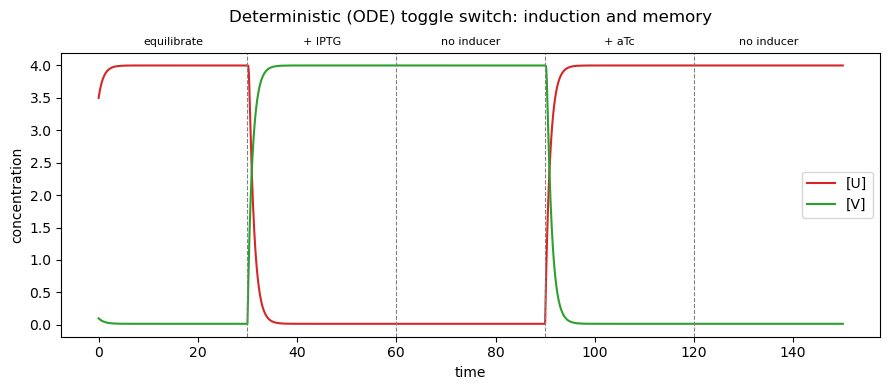

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_ode["time"], df_ode["U"], color="tab:red",   label="[U]")
ax.plot(df_ode["time"], df_ode["V"], color="tab:green", label="[V]")

trans = ax.get_xaxis_transform()
for boundary in phase_bounds[1:-1]:
    ax.axvline(boundary, color="gray", linestyle="--", linewidth=0.8)
for label, start, end in zip(phase_labels, phase_bounds[:-1], phase_bounds[1:]):
    ax.text((start+end)/2, 1.02, label.splitlines()[0],
            ha="center", va="bottom", fontsize=8, transform=trans)

ax.set_xlabel("time")
ax.set_ylabel("concentration")
ax.set_title("Deterministic (ODE) toggle switch: induction and memory", pad=22)
ax.legend(loc="center right")
fig.tight_layout()
plt.show()


## 3. Hysteresis in the (U, V) phase plane

Plotting the same trajectory in `(U, V)` space rather than against time
makes the bistability concrete: the two "no inducer" phases sit at
different corners of the plane even though they share identical
environments — the system's state depends on its history, not just its
current input. That's memory.


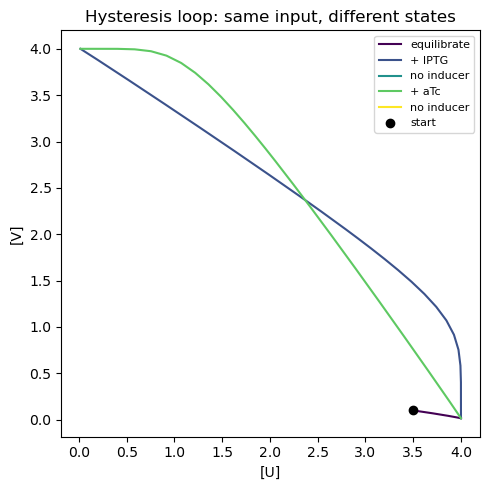

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(phase_labels)))
for label, start, end, color in zip(phase_labels, phase_bounds[:-1], phase_bounds[1:], colors):
    segment = df_ode[(df_ode["time"] >= start) & (df_ode["time"] <= end)]
    ax.plot(segment["U"], segment["V"], color=color, label=label.splitlines()[0])
ax.scatter(df_ode["U"].iloc[0], df_ode["V"].iloc[0], color="black", zorder=5, label="start")
ax.set_xlabel("[U]")
ax.set_ylabel("[V]")
ax.set_title("Hysteresis loop: same input, different states")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 4. Stochastic switching and memory (Gillespie SSA)

The same protocol, but `Simulation(..., simulation_method="SSA")` runs exact
Gillespie stochastic simulation instead of the mean-field ODE. The cell is
given a small volume (`length=8.0`) so molecule counts are low enough for
shot noise to be visible against the deterministic trajectory, while
remaining large enough that the switch reliably flips and remembers each
state (see how closely it tracks the dashed deterministic curve from
section 2).


In [6]:
cell_ssa = Cell(
    id=0, position=[25.0, 25.0], orientation=[1.0, 0.0], length=8.0,
    network=ReactionNetwork("toggle_switch",
                            {"gene_u": gene_u, "gene_v": gene_v, "deg_u": deg_u, "deg_v": deg_v}),
    growth_rate=0.0, rng=np.random.default_rng(7),
)
cell_ssa.set_concentration("U", 3.5)
cell_ssa.set_concentration("V", 0.1)

colony_ssa = Colony([cell_ssa], no_inducer)
sim_ssa = Simulation(colony_ssa, dt=0.05, t_max=phase_duration, simulation_method="SSA")

df_ssa = sim_ssa.run(t_max=1*phase_duration, show_progress=False)  # equilibrate
colony_ssa.switch_environment(add_iptg)
df_ssa = sim_ssa.run(t_max=2*phase_duration, show_progress=False)  # + IPTG
colony_ssa.switch_environment(no_inducer)
df_ssa = sim_ssa.run(t_max=3*phase_duration, show_progress=False)  # memory
colony_ssa.switch_environment(add_atc)
df_ssa = sim_ssa.run(t_max=4*phase_duration, show_progress=False)  # + aTc
colony_ssa.switch_environment(no_inducer)
df_ssa = sim_ssa.run(t_max=5*phase_duration, show_progress=False)  # memory

print(f"cell volume: {cell_ssa.compute_volume():.2f} um^3")


cell volume: 6.81 um^3


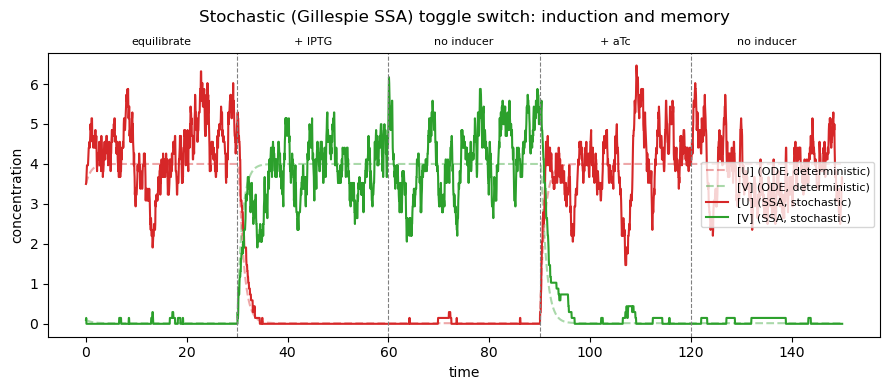

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_ode["time"], df_ode["U"], "--", color="tab:red",   alpha=0.4, label="[U] (ODE, deterministic)")
ax.plot(df_ode["time"], df_ode["V"], "--", color="tab:green", alpha=0.4, label="[V] (ODE, deterministic)")
ax.plot(df_ssa["time"], df_ssa["U"],       color="tab:red",             label="[U] (SSA, stochastic)")
ax.plot(df_ssa["time"], df_ssa["V"],       color="tab:green",           label="[V] (SSA, stochastic)")

trans = ax.get_xaxis_transform()
for boundary in phase_bounds[1:-1]:
    ax.axvline(boundary, color="gray", linestyle="--", linewidth=0.8)
for label, start, end in zip(phase_labels, phase_bounds[:-1], phase_bounds[1:]):
    ax.text((start+end)/2, 1.02, label.splitlines()[0],
            ha="center", va="bottom", fontsize=8, transform=trans)

ax.set_xlabel("time")
ax.set_ylabel("concentration")
ax.set_title("Stochastic (Gillespie SSA) toggle switch: induction and memory", pad=22)
ax.legend(loc="center right", fontsize=8)
fig.tight_layout()
plt.show()


## 5. A growing, dividing colony: animating the switch

Finally, the same circuit in a small *growing* colony — cells divide as the
animation plays. Growth dilution acts like extra degradation, so it's kept
slow (`growth_rate=0.04`, doubling time ~17 time units) relative to the
switch's own ~1 time-unit relaxation rate; otherwise dilution would wash
out the bistability entirely (try raising it to see that happen). Cells are
colored by `[U]` (red) and `[V]` (green) via `visualize_colony()`, so the whole
colony's color should flip together at each induction step and hold after
each induction is removed.


colony grew from 2 to 180 living cells


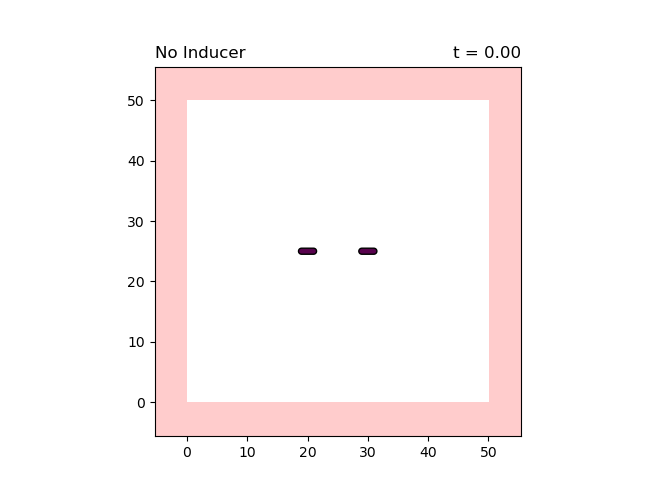

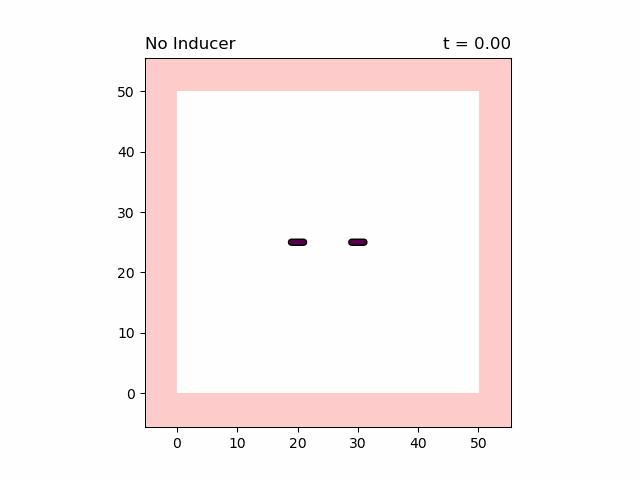

In [8]:
video_shape, video_bounds = (10, 10), (50.0, 50.0)
video_phase_duration = 15.0

video_no_inducer = Environment("No Inducer", wall_map=np.zeros(video_shape), size=video_bounds, fields=[
    Field("IPTG", np.zeros(video_shape), is_chemical=True),
    Field("aTc",  np.zeros(video_shape), is_chemical=True),
])
video_add_iptg = Environment("+IPTG", wall_map=np.zeros(video_shape), size=video_bounds, fields=[
    Field("IPTG", np.full(video_shape, 5.0), is_chemical=True),
    Field("aTc",  np.zeros(video_shape),     is_chemical=True),
])
video_add_atc = Environment("+aTc", wall_map=np.zeros(video_shape), size=video_bounds, fields=[
    Field("IPTG", np.zeros(video_shape),     is_chemical=True),
    Field("aTc",  np.full(video_shape, 5.0), is_chemical=True),
])

video_cells = [
    Cell(
        id=i, position=position, orientation=[1.0, 0.0], length=2.0,
        network=ReactionNetwork("toggle_switch",
                                {"gene_u": gene_u, "gene_v": gene_v, "deg_u": deg_u, "deg_v": deg_v}),
        growth_rate=0.04, rng=np.random.default_rng(i),
    )
    for i, position in enumerate([[20.0, 25.0], [30.0, 25.0]])
]
for c in video_cells:
    c.set_concentration("U", 3.5)
    c.set_concentration("V", 0.1)

colony_video = Colony(video_cells, video_no_inducer, k=10.0, drag=1.0)
sim_video = Simulation(colony_video, dt=0.25, t_max=video_phase_duration, simulation_method="SSA")

df_video = sim_video.run(t_max=1*video_phase_duration, show_progress=False)  # equilibrate
colony_video.switch_environment(video_add_iptg)
df_video = sim_video.run(t_max=2*video_phase_duration, show_progress=False)  # + IPTG
colony_video.switch_environment(video_no_inducer)
df_video = sim_video.run(t_max=4*video_phase_duration, show_progress=False)  # memory
colony_video.switch_environment(video_add_atc)
df_video = sim_video.run(t_max=5*video_phase_duration, show_progress=False)  # + aTc
colony_video.switch_environment(video_no_inducer)
df_video = sim_video.run(t_max=7*video_phase_duration, show_progress=False)  # memory

final = df_video[df_video["time"] == df_video["time"].max()]
print(f"colony grew from {len(video_cells)} to {int(final['alive'].sum())} living cells")

sim_video.visualize_colony(red="U", green="V", stride=4, interval=80,
          save_path="outputs", filename="toggle_switch.gif", show_progress=False)
Image(filename="outputs/toggle_switch.gif")
